# 다변량 정규분포

## 정의
**다변량 정규분포**는 정규분포를 다차원으로 일반화한 것으로 다음과 같이 정의된다:

$$
f(\boldsymbol{x}) = {(2\pi)^{-p/2} \det(\Sigma)^{-1/2}} e^{-\frac{1}{2} (\boldsymbol{x} - \boldsymbol{\mu})^T \Sigma^{-1} (\boldsymbol{x} - \boldsymbol{\mu})}
$$

- $ \boldsymbol{\mu} $: 평균 벡터 ($p$-차원)
- $ \Sigma $: 공분산 행렬 ($p \times p$, 대칭이고 양의 정부호 행렬)
- $ \boldsymbol{x} $: $p$-차원 벡터

## 속성
1. **평균**: $ \text{E}[X] = \boldsymbol{\mu} $
2. **공분산**: $ \text{Cov}(X) = \Sigma $
3. **주변 분포 및 조건부 분포**도 정규분포이다.


# 다변량 정규분포의 조건부 및 주변 분포

## 주변 분포

랜덤벡터 $ X \sim N(\mu, \Sigma) $가 다음과 같이 분할될 때:

$$
X = \begin{bmatrix} X_1 \\ X_2 \end{bmatrix}, \quad
\mu = \begin{bmatrix} \mu_1 \\ \mu_2 \end{bmatrix}, \quad
\Sigma = \begin{bmatrix} \Sigma_{11} & \Sigma_{12} \\ \Sigma_{21} & \Sigma_{22} \end{bmatrix},
$$

주변 분포는 다음과 같다:

$$
X_1 \sim N(\mu_1, \Sigma_{11}),
$$
$$
X_2 \sim N(\mu_2, \Sigma_{22}).
$$

### 주요 속성
다변량 정규분포의 부분집합인 주변 분포는 여전히 정규분포를 유지한다.

---

## 조건부 분포

$ X_2 $가 주어졌을 때 $ X_1 $의 조건부 분포는 다음과 같다:

$$
X_1 | X_2 \sim N(\mu_{1|2}, \Sigma_{1|2}),
$$

여기서:
$$
\mu_{1|2} = \mu_1 + \Sigma_{12} \Sigma_{22}^{-1} (X_2 - \mu_2),
$$
$$
\Sigma_{1|2} = \Sigma_{11} - \Sigma_{12} \Sigma_{22}^{-1} \Sigma_{21}.
$$

### 주요 속성
조건부 분포도 정규분포이며, 그 평균과 공분산은 관측된 $ X_2 $ 값에 따라 달라진다.

---

# 핵심 정리
- 주변 분포는 공분산행렬의 대각 블록에만 의존한다.
- 조건부 평균 ($ \mu_{1|2} $)은 $ X_2 $의 관측 값에 따라 이동한다.
- 조건부 분산 ($ \Sigma_{1|2} $)은 $ X_2 $의 관측이 $ X_1 $에 대한 불확실성을 감소시키는 점을 반영한다.


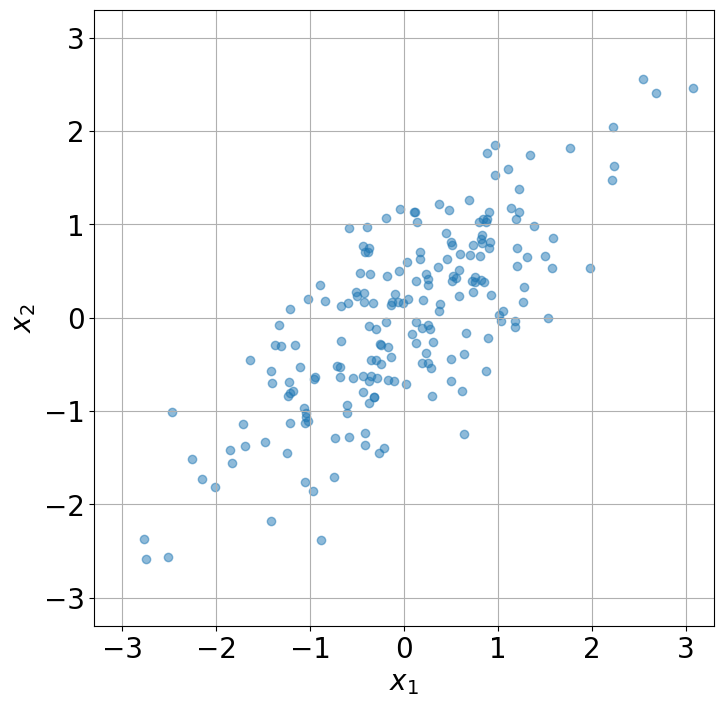

In [ ]:
# 이변량 정규분포 실습

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

plt.rcParams.update({'font.size': 20})  # 전역 폰트 크기를 20로 설정

# 이변량 정규분포의 샘플링
mu = np.array([0, 0])
cov = np.array([[1, 0.8], [0.8, 1]])  # 공분산행렬
mvn_rv = multivariate_normal(mean=mu, cov=cov)
samples = mvn_rv.rvs(size=200, random_state=3)
# 이변량 정규분포 표본의 산점도
fig = plt.figure(figsize=(8, 8))
plt.scatter(samples[:, 0], samples[:, 1], alpha=0.5)
plt.xlim(-3.3, 3.3)
plt.ylim(-3.3, 3.3)
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.grid()
plt.show()

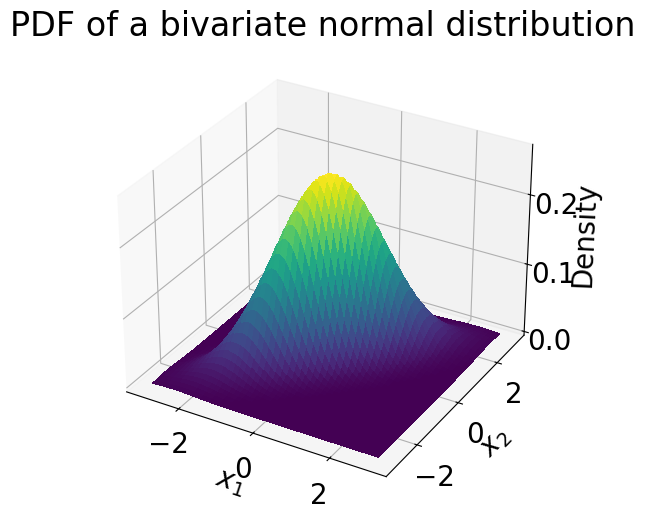

In [ ]:
# 참고) 이변량 정규분포의 Joint PDF: 3D 그림

x1 = np.linspace(-3, 3, 500)
x2 = np.linspace(-3, 3, 500)
X1, X2 = np.meshgrid(x1, x2)
pos = np.dstack((X1, X2))
Z = mvn_rv.pdf(pos)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(1, 1, 1, projection='3d')
ax.plot_surface(X1, X2, Z, cmap='viridis', linewidth=0, antialiased=False)
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_zlabel('Density')
ax.set_title('PDF of a bivariate normal distribution')
plt.show()

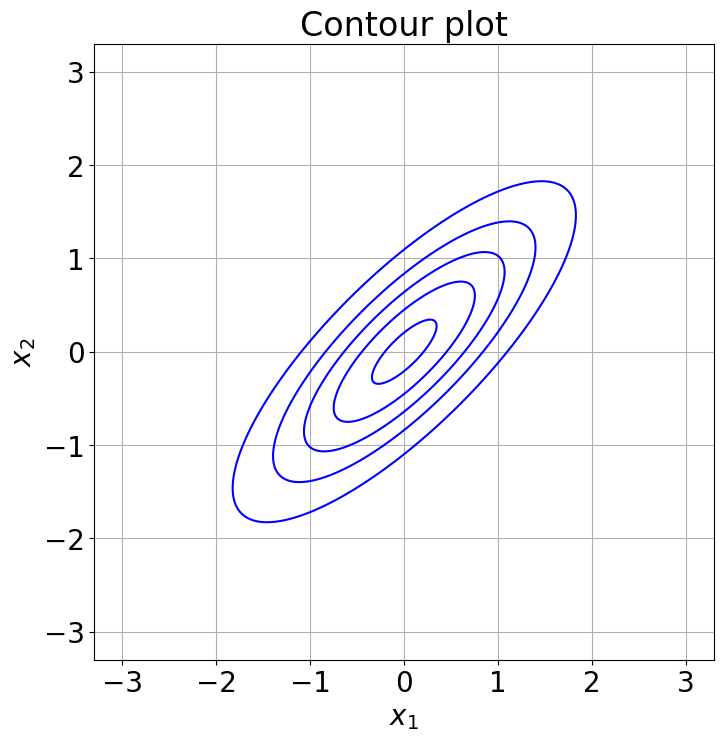

In [ ]:
# 이변량 정규분포의 Joint PDF: 등고선 그림

plt.figure(figsize=(8, 8))
plt.contour(X1, X2, Z, levels=5, colors='blue')
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.xlim(-3.3, 3.3)
plt.ylim(-3.3, 3.3)
plt.title('Contour plot')
plt.grid()
plt.show()

# 고유값 분해 (EVD, Eigenvalue Decomposition)

## 정리
대칭(symmetric)이고 양의 정부호(positive definite)인 행렬 $ \Sigma \in \mathbb{R}^{n \times n} $에 대해, 다음과 같은 분해가 성립한다:

$$
\Sigma = U \Lambda U^T,
$$

여기서:
- $ U $: 정규 직교 행렬 ($ U^T U = I $), 열 벡터는 $ \Sigma $의 고유 벡터이다.
- $ \Lambda $: 대각 행렬 ($ \text{diag}(\lambda_1, \lambda_2, \ldots, \lambda_n) $), $ \Sigma $의 고유값을 포함한다.

## 주요 속성
1. **고유값 ($ \lambda_i $)**: 대칭 양의 정부호 행렬의 모든 고유값은 실수이며 양수이다.
2. **고유벡터 ($ u_i $)**: 고유벡터는 정규 직교 기저를 형성하도록 선택할 수 있다.
3. **분해**: 공분산 행렬은 고유벡터의 가중 조합으로 표현될 수 있다.


In [ ]:
# Eigenvalue Decomposition
eigenval, eigenvec = np.linalg.eigh(cov)
# Reconstruction
reconstructed_cov = eigenvec @ np.diag(eigenval) @ eigenvec.T
# Print results
print("Original Covariance Matrix:")
print(cov)
print("Eigenvalues (λ):")
print(eigenval)
print("Eigenvectors (U):")
print(eigenvec)
print("Reconstructed Covariance Matrix (UΛU^T):")
print(reconstructed_cov)

Original Covariance Matrix:
[[1.  0.8]
 [0.8 1. ]]
Eigenvalues (λ):
[0.2 1.8]
Eigenvectors (U):
[[-0.70710678  0.70710678]
 [ 0.70710678  0.70710678]]
Reconstructed Covariance Matrix (UΛU^T):
[[1.  0.8]
 [0.8 1. ]]


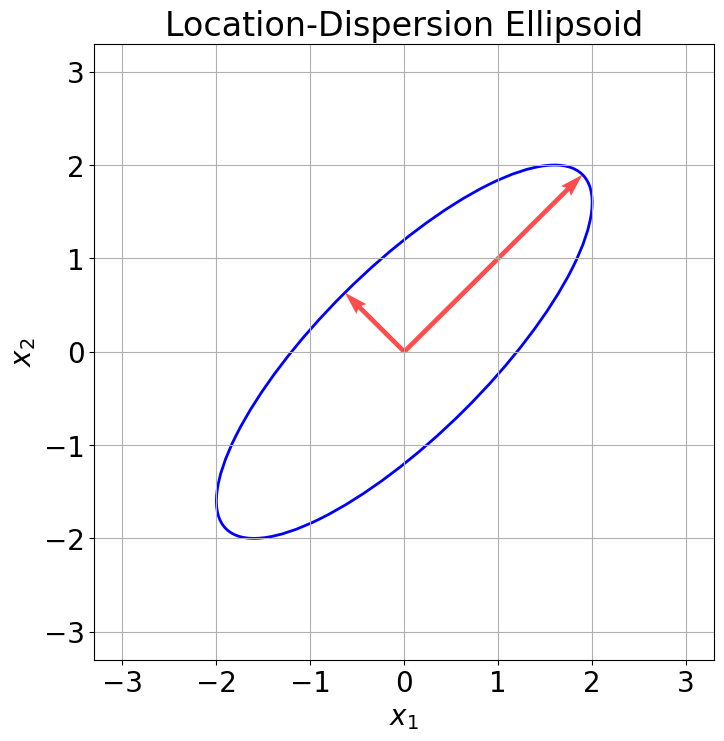

In [ ]:
from matplotlib.patches import Ellipse
# Ellipse parameters
width = 4 * np.sqrt(eigenval[0])  # Major axis (4 SD)
height = 4 * np.sqrt(eigenval[1])  # Minor axis (4 SD)
angle = np.degrees(np.arctan2(eigenvec[1,0],eigenvec[0,0]))

# Plotting
fig, ax = plt.subplots(figsize=(8, 8))
ellipse = Ellipse(xy=mu, width=width, height=height, angle=angle,
                  edgecolor='blue', facecolor='none', linewidth=2)
ax.add_patch(ellipse)

#plt.contour(X1, X2, Z, levels=5, colors='blue')
for i in range(len(eigenval)):
    vector = eigenvec[:, i] * 2 * np.sqrt(eigenval[i])
    ax.quiver(*mu, *vector, angles='xy', scale_units='xy', scale=1, color='red', alpha=0.7)

# Set axes limits and labels
ax.set_xlim(-3.3, 3.3)
ax.set_ylim(-3.3, 3.3)
ax.set_title("Location-Dispersion Ellipsoid")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
plt.grid()
plt.show()

## 그림 설명
1. **중심**: 타원체는 평균 벡터 $ \mu $를 중심으로 가진다.
2. **축**: 축의 길이와 방향은 공분산 행렬 $ \Sigma $의 고유값 ($ \lambda_1, \lambda_2 $)과 고유벡터 ($ u_1, u_2 $)에 의해 결정된다:
   - 장축은 큰 고유값에 해당한다.
   - 단축은 작은 고유값에 해당한다.
3. **방향**: 타원은 고유벡터에 따라 회전된다.

이 시각화는 다변량 정규분포의 위치와 산포를 적절하게 표현한다.

# 주성분 분석 예제)  iris 데이터

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
# 데이터 불러오기
iris = load_iris()
X = iris.data        # (150, 4) — 150송이, 4개 변수
y = iris.target      # 0, 1, 2 — 3종류 붓꽃
print("데이터 크기:", X.shape)
print("변수 이름:", iris.feature_names)
print("앞 5개:\n", X[:5])

데이터 크기: (150, 4)
변수 이름: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
앞 5개:
 [[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]


In [ ]:
# 중심화 (평균 빼기)
X_centered = X - X.mean(axis=0)
# 공분산행렬
cov_matrix = np.cov(X_centered, rowvar=False)
print("공분산행렬:\n", np.round(cov_matrix, 2))
# 고윳값 분해
eigenval, eigenvec = np.linalg.eigh(cov_matrix)
# 큰 순서대로 정렬
idx = eigenval.argsort()[::-1]
eigenval = eigenval[idx]
eigenvec = eigenvec[:, idx]
print("고윳값:", np.round(eigenval, 2))
print("설명 비율:", np.round(eigenval / eigenval.sum() * 100, 1), "%")

공분산행렬:
 [[ 0.69 -0.04  1.27  0.52]
 [-0.04  0.19 -0.33 -0.12]
 [ 1.27 -0.33  3.12  1.3 ]
 [ 0.52 -0.12  1.3   0.58]]
고윳값: [4.23 0.24 0.08 0.02]
설명 비율: [92.5  5.3  1.7  0.5] %


In [ ]:
# PCA 실행 — 2차원으로 축소
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_centered)
print("원래 차원:", X.shape[1])    # 4
print("축소 후:", X_pca.shape[1])  # 2
print("설명 비율:", np.round(pca.explained_variance_ratio_ * 100, 1), "%")

원래 차원: 4
축소 후: 2
설명 비율: [92.5  5.3] %


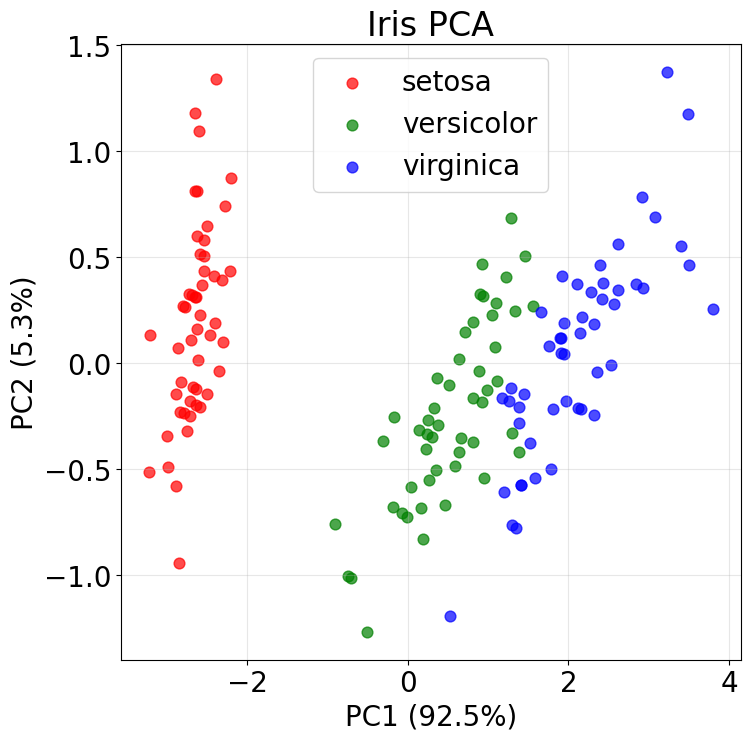

In [ ]:
# PCA 결과 시각화: 산점도 그리기
target_names = iris.target_names
colors = ['red', 'green', 'blue']
fig = plt.figure(figsize=(8, 8))
for i, name in enumerate(target_names):
    mask = (y == i)
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=colors[i], label=name, alpha=0.7, s=60)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('Iris PCA')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# 각 주성분에 대한 변수의 기여도 (loadings)
loadings = pca.components_
feature_names = iris.feature_names
print("PC1 구성:")
for name, val in zip(feature_names, loadings[0]):
    print(f"  {name}: {val:.3f}")
print("\nPC2 구성:")
for name, val in zip(feature_names, loadings[1]):
    print(f"  {name}: {val:.3f}")

PC1 구성:
  sepal length (cm): 0.361
  sepal width (cm): -0.085
  petal length (cm): 0.857
  petal width (cm): 0.358

PC2 구성:
  sepal length (cm): 0.657
  sepal width (cm): 0.730
  petal length (cm): -0.173
  petal width (cm): -0.075


In [ ]:
pca3 = PCA(n_components=3)
X_pca3 = pca3.fit_transform(X_centered)
print("3개 주성분 누적 설명 비율:",
      np.round(pca3.explained_variance_ratio_.sum() * 100, 1), "%")

3개 주성분 누적 설명 비율: 99.5 %


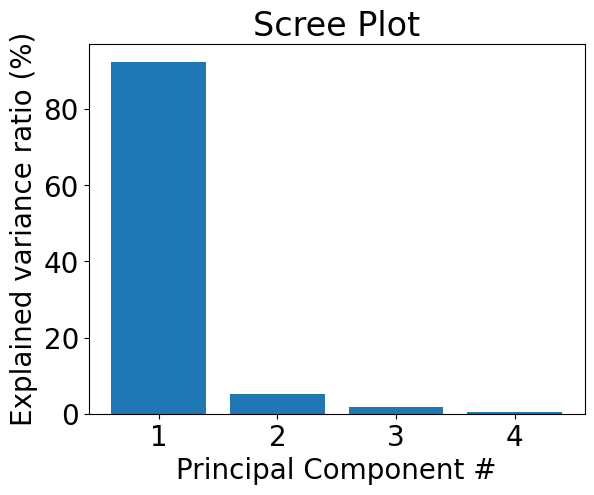

In [ ]:
pca_full = PCA()
pca_full.fit(X_centered)
plt.bar(range(1, 5), pca_full.explained_variance_ratio_ * 100)
plt.xlabel('Principal Component #')
plt.ylabel('Explained variance ratio (%)')
plt.title('Scree Plot')
plt.show()

In [ ]:
# 다른 데이터셋으로 주성분 분석 시도해보기

from sklearn.datasets import load_wine
wine = load_wine()

import numpy as np
import pandas as pd
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler

# (1) Wine 데이터 불러오기 — PPT 마지막 셀과 동일
wine = load_wine()
X = wine.data                 # (178, 13)
feature_names = wine.feature_names
print("데이터 크기:", X.shape)
print("변수 이름:", feature_names)

# (2) 표준화 전 — 평균/표준편차 확인 (스케일이 제각각임을 보임)
df_raw = pd.DataFrame(X, columns=feature_names)
print("\n[표준화 전] 평균:\n", df_raw.mean().round(3))
print("\n[표준화 전] 표준편차:\n", df_raw.std(ddof=0).round(3))

# (3) 13개 변수 모두 표준화
scaler = StandardScaler()
X_std = scaler.fit_transform(X)        # (178, 13)

# (4) 표준화 후 — 평균≈0, 표준편차≈1 인지 확인 (충분한 증거)
df_std = pd.DataFrame(X_std, columns=feature_names)
print("\n[표준화 후] 평균:\n", df_std.mean().round(6))
print("\n[표준화 후] 표준편차:\n", df_std.std(ddof=0).round(6))

# (5) 한눈에 보는 요약 통계 (describe)
print("\n[표준화 후] 요약 통계:\n", df_std.describe().round(4))